## 1. Kurulum ve Bağımlılıklar

## ⚙️ Konfigürasyon — Sadece bu hücreyi değiştir!
Farklı bir branch veya dataset için **yalnızca aşağıdaki hücreyi** güncelle. Geri kalan tüm hücreler buradan okur.


In [14]:
# ============================================================
# PROJE KONFİGÜRASYONU — Branch değiştirince sadece burayı güncelle
# ============================================================

# --- GitHub & Drive ---
REPO_URL        = "https://github.com/panzerofthelake03/DiffuVQA.git"
BRANCH          = "Bio-Bert"
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/DiffuVQA"
LOCAL_CLONE_PATH   = "/content/DiffuVQA"

# --- Model ---
MODEL_NAME      = "Bio-Bert"        # "bert" veya "pubmedbert" "Branch name"
MODEL_LABEL     = "DiffuVQA-Bio-Bert"  # Raporlarda görünecek isim

# --- Dataset ---
DATASET         = "SLAKE"             # "SLAKE", "Kvasir_VQA", "daveKevin" vb.
DATA_DIR        = "datasets"
IMAGEFOLDER_NAME = "SLAKE"
DRIVE_IMAGE_DIR = f"{DRIVE_PROJECT_PATH}/datasets/{IMAGEFOLDER_NAME}/imgs" # daveKevin_images , SLAKE
LOCAL_IMAGE_DIR = f"{LOCAL_CLONE_PATH}/datasets/{IMAGEFOLDER_NAME}/imgs" # daveKevin_images , SLAKE

# Drive'daki dataset görüntü klasörü (birden fazla olası yol)
DATASET_IMG_PATHS = [
    f"/content/drive/MyDrive/datasets/{DATASET}/imgs/imgs",
    f"/content/drive/MyDrive/{DATASET}_dataset/imgs",
    f"/content/drive/Drive'ım/{DATASET}_dataset/imgs",
    f"/content/drive/MyDrive/{DATASET}/imgs",
    f"/content/drive/Drive'ım/{DATASET}/imgs",
]

# --- Eğitim ---
BATCH_SIZE      = 2
LR              = 0.0001
LEARNING_STEPS  = 16000
DIFFUSION_STEPS = 100
SEQ_LEN         = 128
HIDDEN_T_DIM    = 768
SEED            = 42
SAVE_INTERVAL   = 200
LOG_INTERVAL    = 50

# --- Checkpoint & Çıktı ---
CHECKPOINT_PATH = f"/content/drive/MyDrive/DiffuVQA/checkpoints/{DATASET.lower()}/{MODEL_NAME.lower()}/btch{BATCH_SIZE}/lr{LR}"
SAMPLE_FOLDER   = f"/content/drive/MyDrive/DiffuVQA/samples/{DATASET.lower()}/{MODEL_NAME.lower()}"
OUTPUT_CSV      = f"./reports/{MODEL_NAME}_{DATASET.lower()}_evaluation_results.csv"
DRIVE_RESULTS_PATH = "/content/drive/MyDrive/DiffuVQA_Results/"

print("✅ Konfigürasyon yüklendi:")
print(f"   Branch    : {BRANCH}  →  {REPO_URL}")
print(f"   Model     : {MODEL_NAME}")
print(f"   Dataset   : {DATASET}")
print(f"   Checkpoint: {CHECKPOINT_PATH}")


✅ Konfigürasyon yüklendi:
   Branch    : Bio-Bert  →  https://github.com/panzerofthelake03/DiffuVQA.git
   Model     : Bio-Bert
   Dataset   : SLAKE
   Checkpoint: /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch2/lr0.0001


In [2]:
# GPU kontrolü
!nvidia-smi

Wed May  6 11:51:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os
import shutil

# ADIM 1: Colab'daki geçici klasörü temizle (Taze indirme için şart)
if os.path.exists(LOCAL_CLONE_PATH):
    print(f"Eski geçici klasör siliniyor: {LOCAL_CLONE_PATH}")
    shutil.rmtree(LOCAL_CLONE_PATH)

# ADIM 2: GitHub'dan en güncel hali çek
print("GitHub'dan taze kopya çekiliyor...")
!git clone -b {BRANCH} --single-branch {REPO_URL} {LOCAL_CLONE_PATH}

# ADIM 3: Drive'ı GÜNCELLE (dirs_exist_ok=True ile klasör olsa bile içine girip dosyaları yeniler)
print(f"Drive'daki dosyalar güncelleniyor: {DRIVE_PROJECT_PATH}")
if not os.path.exists(DRIVE_PROJECT_PATH):
    os.makedirs(DRIVE_PROJECT_PATH)

shutil.copytree(LOCAL_CLONE_PATH, DRIVE_PROJECT_PATH, dirs_exist_ok=True)
print("\n✅ İŞLEM TAMAM: Yeni dosyalar Drive'a geçti!")

# Çalışma dizinini Drive'daki projeye ayarla
os.chdir(DRIVE_PROJECT_PATH)
print(f"📂 Çalışma dizini: {os.getcwd()}")


GitHub'dan taze kopya çekiliyor...
Cloning into '/content/DiffuVQA'...
remote: Enumerating objects: 972, done.
remote: Counting objects: 100% (335/335), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 972 (delta 237), reused 243 (delta 206), pack-reused 637 (from 3)
Receiving objects: 100% (972/972), 187.58 MiB | 33.60 MiB/s, done.
Resolving deltas: 100% (414/414), done.
Drive'daki dosyalar güncelleniyor: /content/drive/MyDrive/DiffuVQA

✅ İŞLEM TAMAM: Yeni dosyalar Drive'a geçti!
📂 Çalışma dizini: /content/drive/MyDrive/DiffuVQA


In [8]:
# Mevcut bir Drive klonu varsa sadece güncelle (clone yerine alternatif)
if os.path.exists(DRIVE_PROJECT_PATH):
    os.chdir(DRIVE_PROJECT_PATH)
    print(f"📂 Çalışma dizini değiştirildi: {os.getcwd()}")
    print("⬇️ GitHub'dan güncellemeler çekiliyor (git pull)...")
    !git pull
    print("\n✅ Güncelleme tamamlandı. İşte son 3 değişiklik:")
    !git log -3 --oneline
else:
    print("❌ Hata: Drive'da proje klasörü bulunamadı. Önce yukarıdaki clone hücresini çalıştır.")


📂 Çalışma dizini değiştirildi: /content/drive/MyDrive/DiffuVQA
⬇️ GitHub'dan güncellemeler çekiliyor (git pull)...
Already up to date.

✅ Güncelleme tamamlandı. İşte son 3 değişiklik:
a3b426ad (HEAD -> Bio-Bert, origin/Bio-Bert) Inference pipeline update
08b15d9f Update .gitignore
565f871e Update dist_util.py


In [6]:
import os
import shutil
from tqdm.auto import tqdm

# Resolve the first existing path from a list of candidates.
def resolve_dataset_image_source(candidate_paths):
    seen = set()
    for path in candidate_paths:
        if not path or not isinstance(path, str):
            continue
        norm = os.path.normpath(path)
        if norm in seen:
            continue
        seen.add(norm)
        if os.path.exists(path):
            return path
    return None

# Build dataset-local destination from Cell 1 configuration.
dataset_local_root = os.path.join(LOCAL_CLONE_PATH, DATA_DIR, IMAGEFOLDER_NAME)
dataset_local_imgs = os.path.join(dataset_local_root, "imgs")

# Candidate sources in priority order: local config -> DRIVE_IMAGE_DIR -> other dataset candidates.
source_candidates = [
    LOCAL_IMAGE_DIR,
    DRIVE_IMAGE_DIR,
    *DATASET_IMG_PATHS,
    os.path.join(DRIVE_PROJECT_PATH, DATA_DIR, IMAGEFOLDER_NAME, "imgs"),
    os.path.join(DRIVE_PROJECT_PATH, DATA_DIR, DATASET, "imgs"),
]
source_image_path = resolve_dataset_image_source(source_candidates)

# Default active dir for downstream cells.
ACTIVE_IMAGE_DIR = dataset_local_imgs if os.path.exists(dataset_local_imgs) else dataset_local_root

print("Dataset image source candidates:")
for p in source_candidates:
    print(f"  - {p}")

if source_image_path:
    print(f"Using source image path: {source_image_path}")

    src_abs = os.path.abspath(source_image_path)
    dst_abs = os.path.abspath(dataset_local_imgs)

    # Copy files into the local runtime location when source is external.
    if src_abs != dst_abs:
        os.makedirs(dataset_local_imgs, exist_ok=True)

        files_to_copy = []
        for root, _, files in os.walk(source_image_path):
            for file_name in files:
                src_file = os.path.join(root, file_name)
                rel_path = os.path.relpath(src_file, source_image_path)
                dst_file = os.path.join(dataset_local_imgs, rel_path)
                files_to_copy.append((src_file, dst_file))

        for src_file, dst_file in tqdm(files_to_copy, desc="Copying dataset images", unit="file"):
            os.makedirs(os.path.dirname(dst_file), exist_ok=True)
            shutil.copy2(src_file, dst_file)

        print(f"Copied {len(files_to_copy)} files into: {dataset_local_imgs}")
    else:
        print("Source already points to local runtime image directory; skipping copy.")
else:
    print("No configured source image path found; using existing local dataset directory if present.")

# Final active image dir selection for all downstream cells.
if os.path.exists(dataset_local_imgs):
    ACTIVE_IMAGE_DIR = dataset_local_imgs
elif os.path.exists(dataset_local_root):
    ACTIVE_IMAGE_DIR = dataset_local_root
elif source_image_path and os.path.exists(source_image_path):
    ACTIVE_IMAGE_DIR = source_image_path

print(f"ACTIVE_IMAGE_DIR set to: {ACTIVE_IMAGE_DIR}")

Dataset image source candidates:
  - /content/DiffuVQA/datasets/SLAKE/imgs
  - /content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs
  - /content/drive/MyDrive/datasets/SLAKE/imgs/imgs
  - /content/drive/MyDrive/SLAKE_dataset/imgs
  - /content/drive/Drive'ım/SLAKE_dataset/imgs
  - /content/drive/MyDrive/SLAKE/imgs
  - /content/drive/Drive'ım/SLAKE/imgs
  - /content/drive/MyDrive/DiffuVQA/SLAKE/SLAKE/imgs
  - /content/drive/MyDrive/DiffuVQA/SLAKE/SLAKE/imgs
Using source image path: /content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs


Copying dataset images:   0%|          | 0/2592 [00:00<?, ?file/s]

Copied 2592 files into: /content/DiffuVQA/SLAKE/SLAKE/imgs
ACTIVE_IMAGE_DIR set to: /content/DiffuVQA/SLAKE/SLAKE/imgs


In [ ]:
# Dataset yapısını kontrol et
import os

active_image_dir = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR

!echo "📂 Dataset klasörü:"
!ls -lh datasets/
!echo "\n📊 JSONL dosyaları:"
!ls -lh datasets/*.jsonl
print(f"\n🖼️ Active image dir: {active_image_dir}")
if os.path.exists(active_image_dir):
    try:
        print("İlk 5 dosya:")
        for i, name in enumerate(sorted(os.listdir(active_image_dir))[:5], 1):
            print(f"  {i}. {name}")
    except Exception as e:
        print(f"⚠️ Image dir listelenemedi: {e}")
else:
    print("⚠️ Active image dir bulunamadı.")

!echo "\n📄 Train set örneği:"
!head -n 1 datasets/train.jsonl


📂 Dataset klasörü:
total 3.4M
drwx------ 4 root root 4.0K Dec 17 20:24 daveKevin_images
-rw------- 1 root root 132K Mar  2 10:01 daveKevin_samples_test.png
-rw------- 1 root root 158K Mar  2 14:18 daveKevin_samples_train.png
-rw------- 1 root root 179K Mar  2 14:19 daveKevin_samples_valid.png
-rw------- 1 root root 136K Mar 11 22:42 daveKevin_test_first3_preview.png
-rw------- 1 root root 149K Mar 11 19:51 daveKevin_train_first3_preview.png
-rw------- 1 root root 174K Mar 11 19:53 daveKevin_valid_first3_preview.png
drwx------ 3 root root 4.0K Mar  5 10:12 SLAKE
-rw------- 1 root root 170K Mar 20 14:50 SLAKE_test_first3_preview.png
-rw------- 1 root root 107K Mar 20 13:52 SLAKE_train_first3_preview.png
-rw------- 1 root root 100K Mar 20 13:52 SLAKE_valid_first3_preview.png
-rw------- 1 root root 324K Apr 19 12:33 test.jsonl
-rw------- 1 root root 1.5M Apr 19 12:33 train.jsonl
-rw------- 1 root root 322K Apr 19 12:33 valid.jsonl
\n📊 JSONL dosyaları:
-rw------- 1 root root 324K Apr 19 12:

Searching for images in: /content/DiffuVQA/SLAKE/SLAKE/imgs
Found 1289 images.


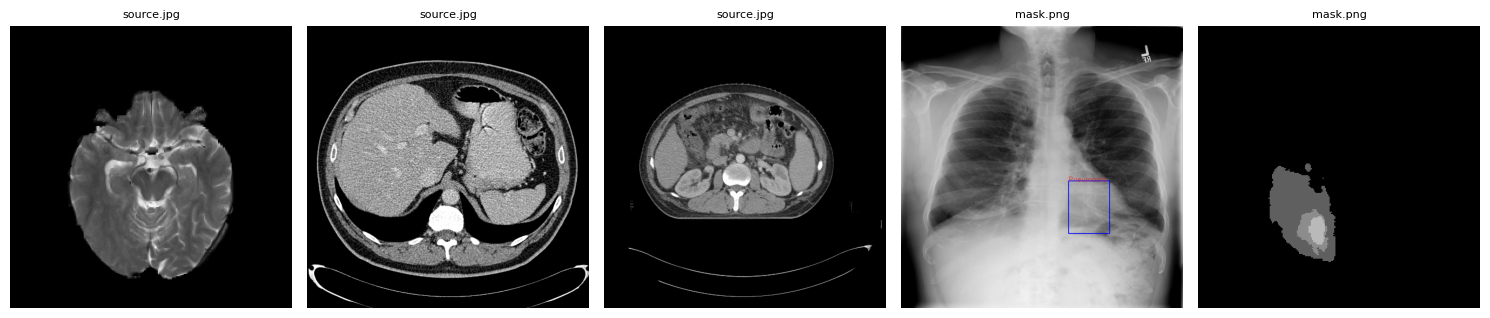

✅ Displayed 5 example images.


In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# Use dataset-agnostic active image dir prepared in previous cell.
image_folder_path = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR
print(f"Searching for images in: {image_folder_path}")

image_extensions = (".png", ".jpg", ".jpeg", ".gif", ".bmp", ".tiff")
all_image_files = []
for root, _, files in os.walk(image_folder_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            all_image_files.append(os.path.join(root, file))

if not all_image_files:
    print(f"⚠️ No images found in {image_folder_path}. Please check path/config.")
else:
    print(f"Found {len(all_image_files)} images.")
    num_examples = min(5, len(all_image_files))
    selected_images = random.sample(all_image_files, num_examples)

    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(selected_images):
        try:
            img = Image.open(img_path)
            plt.subplot(1, num_examples, i + 1)
            plt.imshow(img)
            plt.title(os.path.basename(img_path), fontsize=8)
            plt.axis("off")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            plt.subplot(1, num_examples, i + 1)
            plt.text(0.5, 0.5, "Error", horizontalalignment="center", verticalalignment="center", transform=plt.gca().transAxes, color="red")
            plt.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"✅ Displayed {num_examples} example images.")

In [15]:
# vqa_datasets __main__ test (runs the module exactly like a script)
import os
import sys
import subprocess

# Ensure we run from project root
os.chdir(DRIVE_PROJECT_PATH)
print(f"cwd: {os.getcwd()}")

# Use dataset-agnostic image dir
data_dir = DATA_DIR
image_dir = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR
dataset_name = DATASET

cmd = [
    sys.executable,
    "-m",
    "diffuvqa.vqa_datasets",
    "--data_dir", data_dir,
    "--dataset", dataset_name,
    "--image_dir", image_dir,
    "--vocab", MODEL_NAME.lower(),
    "--config_name", "bert-base-uncased" if MODEL_NAME.lower() == "bert" else MODEL_NAME,
    "--batch_size", "1",
    "--seq_len", "64",
    "--image_size", "224",
]

print("Running command:")
print(" ".join(cmd))
print("-" * 80)

result = subprocess.run(cmd, text=True, capture_output=True)
print(result.stdout)
if result.stderr:
    print("[stderr]")
    print(result.stderr)

print("-" * 80)
print(f"Return code: {result.returncode}")
if result.returncode != 0:
    print("vqa_datasets __main__ test failed. Check logs above for missing path/dependency details.")
else:
    print("vqa_datasets __main__ test completed successfully.")

cwd: /content/drive/MyDrive/DiffuVQA
Running command:
/usr/bin/python3 -m diffuvqa.vqa_datasets --data_dir datasets --dataset SLAKE --image_dir /content/DiffuVQA/SLAKE/SLAKE/imgs --vocab bio-bert --config_name Bio-Bert --batch_size 1 --seq_len 64 --image_size 224
--------------------------------------------------------------------------------
save tokenizer to diffuvqa/config
reload the random embeddings Embedding(28996, 1024)
Logging to /tmp/openai-2026-05-06-12-17-45-743848
##############################
Loading text data...
##############################
Loading dataset SLAKE from datasets...
### Loading from the TRAIN set...
### Data samples...
questions: ['What modality is used to take this image?', 'Which part of the body does this image belong to?'] answers: ['MRI', 'Abdomen'] images: ['imgs/xmlab1/source.jpg', 'imgs/xmlab1/source.jpg']
Attempted image path: /content/DiffuVQA/SLAKE/SLAKE/imgs/imgs/xmlab1/source.jpg
Parent folder of attempted image path: /content/DiffuVQA/SLAKE/S

In [11]:
# Bağımlılıkları yükle
# Colab PyTorch ile geliyor, o yüzden requirements_colab.txt kullanıyoruz
!pip install --upgrade pip
!pip install -r requirements_colab.txt
!pip install pandas openpyxl bert-score  # Excel support ve BERTScore için
!python -m spacy download en_core_web_sm

print("\n✅ Kurulum tamamlandı!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 57.1 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [bert_score]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 41.1 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

✅ Kurulum tamamlandı!


In [12]:
# Gerekli kütüphaneleri içe aktar
import os
import sys
import json
import torch
import pandas as pd
import numpy as np
from datetime import datetime
from collections import defaultdict
import glob

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
!pip install torchmetrics

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 7.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchmetrics]


## 2. Model Eğitimi


In [16]:
import os
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

train_image_dir = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR
print(f"Training with image_dir: {train_image_dir}")

!python train.py \
    --vocab {MODEL_NAME.lower()} \
    --use_plm_init {MODEL_NAME} \
    --batch_size {BATCH_SIZE} \
    --lr {LR} \
    --diffusion_steps {DIFFUSION_STEPS} \
    --seq_len {SEQ_LEN} \
    --hidden_t_dim {HIDDEN_T_DIM} \
    --checkpoint_path {CHECKPOINT_PATH} \
    --seed {SEED} \
    --learning_steps {LEARNING_STEPS} \
    --save_interval {SAVE_INTERVAL} \
    --log_interval {LOG_INTERVAL} \
    --data_dir {DATA_DIR} \
    --dataset {DATASET} \
    --image_dir {train_image_dir}


Training with image_dir: /content/DiffuVQA/SLAKE/SLAKE/imgs
Logging to /tmp/openai-2026-05-06-12-18-02-553988
### Creating data loader...
save tokenizer to /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch2/lr0.0001
reload the random embeddings Embedding(28996, 768)
##############################
Loading text data...
##############################
Loading dataset SLAKE from datasets...
### Loading from the TRAIN set...
### Data samples...
questions: ['What modality is used to take this image?', 'Which part of the body does this image belong to?'] answers: ['MRI', 'Abdomen'] images: ['imgs/xmlab1/source.jpg', 'imgs/xmlab1/source.jpg']
Attempted image path: /content/DiffuVQA/SLAKE/SLAKE/imgs/imgs/xmlab1/source.jpg
Parent folder of attempted image path: /content/DiffuVQA/SLAKE/SLAKE/imgs/imgs/xmlab1
Inside parent folder (/content/DiffuVQA/SLAKE/SLAKE/imgs/imgs/xmlab1): ['question.json', 'source.jpg', 'detection.json', 'mask.png']
### Loading image for preview: /content/Diffu

## 3. Model Örnekleme (Inference)

In [17]:
# Test seti üzerinde örnekleme yap
# Checkpoint dosyasını otomatik bul
checkpoint_files = sorted(glob.glob(f"{CHECKPOINT_PATH}/ema_*.pt"))
SAMPLE_STEP = 50
SAMPLE_SEED2 = 105

if checkpoint_files:
    checkpoint_file = checkpoint_files[-1]
    print(f"📂 Kullanılacak checkpoint: {checkpoint_file}")
else:
    print("⚠️ Checkpoint bulunamadı! Lütfen önce eğitimi tamamlayın.")
    checkpoint_file = None

if checkpoint_file:
    !python sample_vqa_GPU.py \
        --model_path {checkpoint_file} \
        --step {SAMPLE_STEP} \
        --batch_size {BATCH_SIZE} \
        --seed2 {SAMPLE_SEED2} \
        --split test \
        --out_dir {SAMPLE_FOLDER} \
        --clamp_step 0

    print(f"\n✅ Örnekleme tamamlandı!")
    print(f"📂 Çıktı dosyaları {SAMPLE_FOLDER} klasöründe oluşturuldu.")
    !echo "\n📄 Oluşturulan sample dosyaları:"
    !ls -lh {SAMPLE_FOLDER}*.jsonl | tail -5


📂 Kullanılacak checkpoint: /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch2/lr0.0001/ema_0.9999_016000.pt
Logging to /tmp/openai-2026-05-06-15-55-15-732860
DEBUG: Parsed model_path = /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch2/lr0.0001/ema_0.9999_016000.pt
### Loading model from /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch2/lr0.0001/ema_0.9999_016000.pt
config_path: /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch2/lr0.0001/training_args.json
### Updated args: Namespace(model_path='/content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch2/lr0.0001/ema_0.9999_016000.pt', step=50, out_dir='/content/drive/MyDrive/DiffuVQA/samples/slake/bio-bert', top_p=0, lr=0.0001, batch_size=2, learning_steps=16000, microbatch=64, log_interval=50, save_interval=200, eval_interval=500, valid=True, ema_rate='0.9999', resume_checkpoint='none', schedule_sampler='lossaware', diffusion_steps=100, noise_schedule='sqrt', timestep_resp

In [ ]:
# compare_image_black_vectors.py hızlı test hücresi (dataset-safe + import-safe + error-aware)
import glob
import os
import sys
import subprocess

# Komutu proje kökünden çalıştır ki `diffuvqa` import'u çözülsün
os.chdir(DRIVE_PROJECT_PATH)
print(f"📂 Çalışma dizini: {os.getcwd()}")

checkpoint_files = sorted(glob.glob(f"{CHECKPOINT_PATH}/ema_*.pt"))

if checkpoint_files:
    checkpoint_file = checkpoint_files[-1]
    print(f"📂 Vector karşılaştırma için checkpoint: {checkpoint_file}")
else:
    print("⚠️ Checkpoint bulunamadı. Önce eğitim/örnekleme hücrelerini çalıştır.")
    checkpoint_file = None

if checkpoint_file:
    os.makedirs("./outputs", exist_ok=True)
    out_jsonl = f"./outputs/{MODEL_NAME}_{DATASET.lower()}_real_vs_black_vectors.jsonl"
    out_pt = f"./outputs/{MODEL_NAME}_{DATASET.lower()}_real_vs_black_vectors.pt"

    image_dir_arg = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR
    print(f"🧭 compare dataset: {DATASET} | data_dir: {DATA_DIR} | image_dir: {image_dir_arg}")

    cmd = [
        sys.executable,
        "-m", "scripts.compare_image_black_vectors",
        "--model_path", checkpoint_file,
        "--split", "test",
        "--batch_size", str(BATCH_SIZE),
        "--max_samples", "50",
        "--data_dir", DATA_DIR,
        "--dataset", DATASET,
        "--image_dir", image_dir_arg,
        "--out_jsonl", out_jsonl,
        "--out_pt", out_pt,
    ]

    print("🚀 Komut çalıştırılıyor:")
    print(" ".join(cmd))

    result = subprocess.run(cmd, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print("[stderr]")
        print(result.stderr)

    if result.returncode == 0 and os.path.exists(out_jsonl):
        print("\n✅ Vector comparison testi tamamlandı")
        print(f"📄 JSONL: {out_jsonl}")
        print(f"🧠 PT   : {out_pt}")
        print("\n📌 İlk 3 satır:")
        with open(out_jsonl, "r", encoding="utf-8") as f:
            for idx, line in enumerate(f):
                if idx >= 3:
                    break
                print(line.rstrip())
    else:
        print(f"⚠️ Vector comparison başarısız (return code: {result.returncode}).")
        print("Logları kontrol et. Gerekirse PYTHONPATH ayarı ile tekrar deneyebilirsin.")

📂 Çalışma dizini: /content/drive/MyDrive/DiffuVQA
📂 Vector karşılaştırma için checkpoint: /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bert/btch2/lr0.0001/ema_0.9999_004000.pt
🧭 compare dataset: SLAKE | data_dir: datasets | image_dir: /content/DiffuVQA/datasets
🚀 Komut çalıştırılıyor:
/usr/bin/python3 -m scripts.compare_image_black_vectors --model_path /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bert/btch2/lr0.0001/ema_0.9999_004000.pt --split test --batch_size 2 --max_samples 50 --data_dir datasets --dataset SLAKE --image_dir /content/DiffuVQA/datasets --out_jsonl ./outputs/Bert_slake_real_vs_black_vectors.jsonl --out_pt ./outputs/Bert_slake_real_vs_black_vectors.pt
Logging to /tmp/openai-2026-03-11-09-24-24-687014
Loading model from: /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bert/btch2/lr0.0001/ema_0.9999_004000.pt
Using device: cuda
initializing from pretrained bert...
BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "

## 4. Model Değerlendirme ve CSV Export

In [ ]:
# İlk olarak eval_DiffuVQA.py ile değerlendir.

CURRENT_SAMPLE_FILENAME = f"ema_0.9999_004000.pt.seed102_step0_samplestep{SAMPLE_STEP}_bsize{BATCH_SIZE}.jsonl"

!python eval_DiffuVQA.py --folder {SAMPLE_FOLDER} --filename {"ema_0.9999_004000.pt.seed102_step0_samplestep50_bsize2"}

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
Enhanced metrics loaded successfully!
Excel export module loaded successfully!
save tokenizer to diffuvqa/config
/content/drive/MyDrive/DiffuVQA/samples/slake/bert
Traceback (most recent call last):
  File "/content/drive/MyDrive/DiffuVQA/eval_DiffuVQA.py", line 218, in <module>
    with open(files[0], 'r') as f:
         ^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/DiffuVQA/samples/slake/bert/ema_0.9999_004000.pt.seed102_step0_samplestep50_bsize2'


In [ ]:
# Değerlendirme fonksiyonları
from torchmetrics.text.rouge import ROUGEScore
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk

# NLTK veri setlerini indir
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

rougeScore = ROUGEScore()

def get_bleu(recover, reference, n=1):
    """BLEU-n score"""
    weights = tuple((1.0 / n for _ in range(n)))
    return sentence_bleu([reference.split()], recover.split(),
                        weights=weights,
                        smoothing_function=SmoothingFunction().method4)

def rouge_l_score(prediction, reference):
    """ROUGE-L score"""
    scores = rougeScore(prediction, reference)
    return scores['rougeL_fmeasure'].item()

def calculate_meteor(prediction, reference):
    """METEOR score"""
    return meteor_score([word_tokenize(reference)], word_tokenize(prediction))

def cider_score(predictions, references):
    """CIDEr-like score using TF-IDF cosine similarity"""
    if not predictions or not references:
        return 0.0
    try:
        vectorizer = TfidfVectorizer()
        tfidf_matrix = vectorizer.fit_transform(predictions + references)
        n_pred = len(predictions)
        pred_vectors = tfidf_matrix[:n_pred]
        ref_vectors = tfidf_matrix[n_pred:]
        similarities = cosine_similarity(pred_vectors, ref_vectors)
        return similarities.diagonal().mean()
    except:
        return 0.0

print("✅ Değerlendirme fonksiyonları hazır")


✅ Değerlendirme fonksiyonları hazır


In [ ]:
def evaluate_and_export_csv(sample_files, output_csv="evaluation_results.csv", dataset_file="datasets/test.jsonl",
                            model_label="DiffuVQA", dataset_label="SLAKE"):
    """
    Örneklenmiş model çıktılarını değerlendir ve CSV'ye kaydet

    Args:
        sample_files: JSONL formatında örnek dosyaları (liste veya tek dosya)
        output_csv: Çıktı CSV dosya yolu
        dataset_file: Original dataset (answer_type bilgisi için)
        model_label: Raporda görünecek model ismi
        dataset_label: Raporda görünecek dataset ismi
    """
    if isinstance(sample_files, str):
        sample_files = [sample_files]

    # Dataset'ten answer_type mapping'i oluştur
    print(f"📂 Dataset'ten answer_type bilgisi yükleniyor: {dataset_file}")
    answer_type_map = {}
    try:
        with open(dataset_file, 'r', encoding='utf-8') as f:
            for line in f:
                data = json.loads(line)
                qid = data.get('qid')
                question = data.get('question', '').strip().lower()
                answer_type = data.get('answer_type', 'UNKNOWN')

                if qid:
                    answer_type_map[qid] = answer_type
                if question:
                    answer_type_map[question] = answer_type
        print(f"✅ {len(answer_type_map)} answer_type mapping yüklendi")
    except Exception as e:
        print(f"⚠️ Dataset yüklenemedi: {e}")
        answer_type_map = {}

    all_results = []

    for sample_file in sample_files:
        print(f"\n📊 Değerlendiriliyor: {sample_file}")

        samples = []
        with open(sample_file, 'r', encoding='utf-8') as f:
            for line in f:
                samples.append(json.loads(line))

        print(f"✅ {len(samples)} satır okundu")

        bleu1_scores = []
        rougeL_scores = []
        meteor_scores = []
        f1_scores = []
        predictions = []
        references = []

        total_samples = 0
        correct_all = 0
        correct_yn = 0
        correct_oe = 0
        count_yn = 0
        count_oe = 0
        empty_count = 0

        for sample in samples:
            pred = (sample.get('generate_answer') or
                   sample.get('recover') or
                   sample.get('generated_answer') or
                   sample.get('prediction') or '').strip()

            ref = (sample.get('reference_answer') or
                  sample.get('reference') or
                  sample.get('answer') or '').strip()

            q_type = sample.get('answer_type', 'UNKNOWN')

            if q_type == 'UNKNOWN':
                qid = sample.get('qid')
                question = sample.get('question', '').strip().lower()

                if qid and qid in answer_type_map:
                    q_type = answer_type_map[qid]
                elif question and question in answer_type_map:
                    q_type = answer_type_map[question]

            if not ref:
                continue

            if not pred:
                empty_count += 1
                pred = "[EMPTY]"

            predictions.append(pred)
            references.append(ref)

            em = 1.0 if pred.lower().strip() == ref.lower().strip() else 0.0

            total_samples += 1
            if em == 1.0:
                correct_all += 1
                if q_type == 'CLOSED':
                    correct_yn += 1
                elif q_type == 'OPEN':
                    correct_oe += 1

            if q_type == 'CLOSED':
                count_yn += 1
            elif q_type == 'OPEN':
                count_oe += 1

            if pred != "[EMPTY]":
                pred_tokens = set(pred.lower().split())
                ref_tokens = set(ref.lower().split())
                if len(pred_tokens) == 0 or len(ref_tokens) == 0:
                    f1 = 0.0
                else:
                    precision = len(pred_tokens & ref_tokens) / len(pred_tokens)
                    recall = len(pred_tokens & ref_tokens) / len(ref_tokens)
                    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
                f1_scores.append(f1)
            else:
                f1_scores.append(0.0)

            bleu1_scores.append(get_bleu(pred, ref, n=1) if pred != "[EMPTY]" else 0.0)
            rougeL_scores.append(rouge_l_score(pred, ref) if pred != "[EMPTY]" else 0.0)
            meteor_scores.append(calculate_meteor(pred, ref) if pred != "[EMPTY]" else 0.0)

        cider = cider_score(predictions, references) if predictions else 0.0

        print("⏳ BERTScore hesaplanıyor...")
        try:
            from bert_score import score as bert_score_fn
            valid_preds = [p for p in predictions if p != "[EMPTY]"]
            valid_refs = [r for i, r in enumerate(references) if predictions[i] != "[EMPTY]"]

            if valid_preds and valid_refs:
                bert_precision, bert_recall, bert_f1 = bert_score_fn(
                    valid_preds, valid_refs, lang='en', verbose=False, device='cuda' if torch.cuda.is_available() else 'cpu'
                )
                bert_f1_score = bert_f1.mean().item()
            else:
                bert_f1_score = 0.0
        except Exception as e:
            print(f"⚠️ BERTScore hesaplanamadı: {e}")
            bert_f1_score = 0.0

        print(f"\n📋 Answer Type Dağılımı:")
        print(f"  CLOSED sorular: {count_yn}")
        print(f"  OPEN sorular: {count_oe}")
        print(f"  UNKNOWN: {total_samples - count_yn - count_oe}")

        sample_folder_path = os.path.dirname(sample_file) if os.path.dirname(sample_file) else "./samples"

        results = {
            'model_name': model_label,
            'dataset_name': dataset_label,
            'export_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'overall_accuracy': correct_all / total_samples if total_samples > 0 else 0.0,
            'yes_no_accuracy': correct_yn / count_yn if count_yn > 0 else 0.0,
            'open_ended_accuracy': correct_oe / count_oe if count_oe > 0 else 0.0,
            'bleu_1_score': np.mean(bleu1_scores) if bleu1_scores else 0.0,
            'rouge_l_score': np.mean(rougeL_scores) if rougeL_scores else 0.0,
            'meteor_score': np.mean(meteor_scores) if meteor_scores else 0.0,
            'cider_score': cider,
            'bert_score': bert_f1_score,
            'f1_score': np.mean(f1_scores) if f1_scores else 0.0,
            'additional_info': f"Empty: {empty_count} ({100*empty_count/total_samples:.1f}%)" if total_samples > 0 else "",
            'Sample Folder': sample_folder_path,
            'Total Samples': total_samples,
            'Evaluation Date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'File Count': 1
        }

        all_results.append(results)

        print(f"\n📈 Sonuçlar - {os.path.basename(sample_file)}:")
        print(f"  Total Samples: {results['Total Samples']}")
        print(f"  Overall Accuracy: {results['overall_accuracy']:.4f}")
        print(f"  Yes/No Accuracy: {results['yes_no_accuracy']:.4f}")
        print(f"  Open-Ended Accuracy: {results['open_ended_accuracy']:.4f}")
        print(f"  F1 Score: {results['f1_score']:.4f}")
        print(f"  BLEU-1: {results['bleu_1_score']:.4f}")
        print(f"  ROUGE-L: {results['rouge_l_score']:.4f}")
        print(f"  METEOR: {results['meteor_score']:.4f}")
        print(f"  CIDEr: {results['cider_score']:.4f}")
        print(f"  BERTScore: {results['bert_score']:.4f}")

    df = pd.DataFrame(all_results)
    df.to_csv(output_csv, index=False, encoding='utf-8')
    print(f"\n✅ Sonuçlar CSV'ye kaydedildi: {output_csv}")
    return df

print("✅ CSV export fonksiyonu hazır")


✅ CSV export fonksiyonu hazır


In [ ]:
# Tüm örnek dosyalarını değerlendir
sample_files = glob.glob(f"{SAMPLE_FOLDER}/*.jsonl")

os.makedirs("./reports", exist_ok=True)

if not sample_files:
    print("⚠️ Örnek dosyası bulunamadı!")
    print(f"💡 Lütfen önce örnekleme hücresini çalıştırın.")
    print(f"   Checkpoint: {CHECKPOINT_PATH}/ema_0.9999_*.pt")
else:
    print(f"📂 {len(sample_files)} örnek dosyası bulundu")
    results_df = evaluate_and_export_csv(
        sample_files,
        output_csv=OUTPUT_CSV,
        model_label=MODEL_LABEL,
        dataset_label=DATASET,
    )
    print("\n" + "="*80)
    print("📊 TÜM SONUÇLAR:")
    print("="*80)
    display(results_df)


📂 1 örnek dosyası bulundu
📂 Dataset'ten answer_type bilgisi yükleniyor: datasets/test.jsonl
✅ 1380 answer_type mapping yüklendi

📊 Değerlendiriliyor: /content/drive/MyDrive/DiffuVQA/samples/slake/bert/ema_0.9999_004000.pt.seed102_step0_samplestep50_bsize2.jsonl
✅ 2120 satır okundu
⏳ BERTScore hesaplanıyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📋 Answer Type Dağılımı:
  CLOSED sorular: 762
  OPEN sorular: 1140
  UNKNOWN: 218

📈 Sonuçlar - ema_0.9999_004000.pt.seed102_step0_samplestep50_bsize2.jsonl:
  Total Samples: 2120
  Overall Accuracy: 0.7811
  Yes/No Accuracy: 0.9659
  Open-Ended Accuracy: 0.6456
  F1 Score: 0.8324
  BLEU-1: 0.8202
  ROUGE-L: 0.8327
  METEOR: 0.4986
  CIDEr: 0.7827
  BERTScore: 0.9899

✅ Sonuçlar CSV'ye kaydedildi: ./reports/Bert_slake_evaluation_results.csv

📊 TÜM SONUÇLAR:


,model_name,dataset_name,export_date,overall_accuracy,yes_no_accuracy,open_ended_accuracy,bleu_1_score,rouge_l_score,meteor_score,cider_score,bert_score,f1_score,additional_info,Sample Folder,Total Samples,Evaluation Date,File Count
0,DiffuVQA-Bert,SLAKE,2026-03-10 12:35:12,0.781132,0.965879,0.645614,0.82023,0.832726,0.498627,0.782685,0.989875,0.832423,Empty: 254 (12.0%),/content/drive/MyDrive/DiffuVQA/samples/slake/...,2120,2026-03-10 12:35:12,1


## 5. Sonuçları İndir

In [ ]:
# CSV dosyasını Google Drive'a kaydet ve indir
from google.colab import files

os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)

if os.path.exists(OUTPUT_CSV):
    shutil.copy(OUTPUT_CSV, DRIVE_RESULTS_PATH)
    print(f"✅ CSV Google Drive'a kaydedildi: {DRIVE_RESULTS_PATH}")
    files.download(OUTPUT_CSV)
    print(f"✅ {OUTPUT_CSV} bilgisayarınıza indirildi")
else:
    print(f"⚠️ CSV dosyası bulunamadı: {OUTPUT_CSV}")
    print("💡 Lütfen önce değerlendirme hücresini çalıştırın.")

# Checkpoint'leri de Drive'a yedekle (opsiyonel)
print("\n💾 Checkpoint'leri yedeklemek ister misiniz?")
print(f"   # !cp -r {CHECKPOINT_PATH} /content/drive/MyDrive/DiffuVQA_Checkpoints/")


✅ CSV Google Drive'a kaydedildi: /content/drive/MyDrive/DiffuVQA_Results/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ ./reports/Bert_slake_evaluation_results.csv bilgisayarınıza indirildi

💾 Checkpoint'leri yedeklemek ister misiniz?
   # !cp -r /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bert/btch2/lr0.0001 /content/drive/MyDrive/DiffuVQA_Checkpoints/


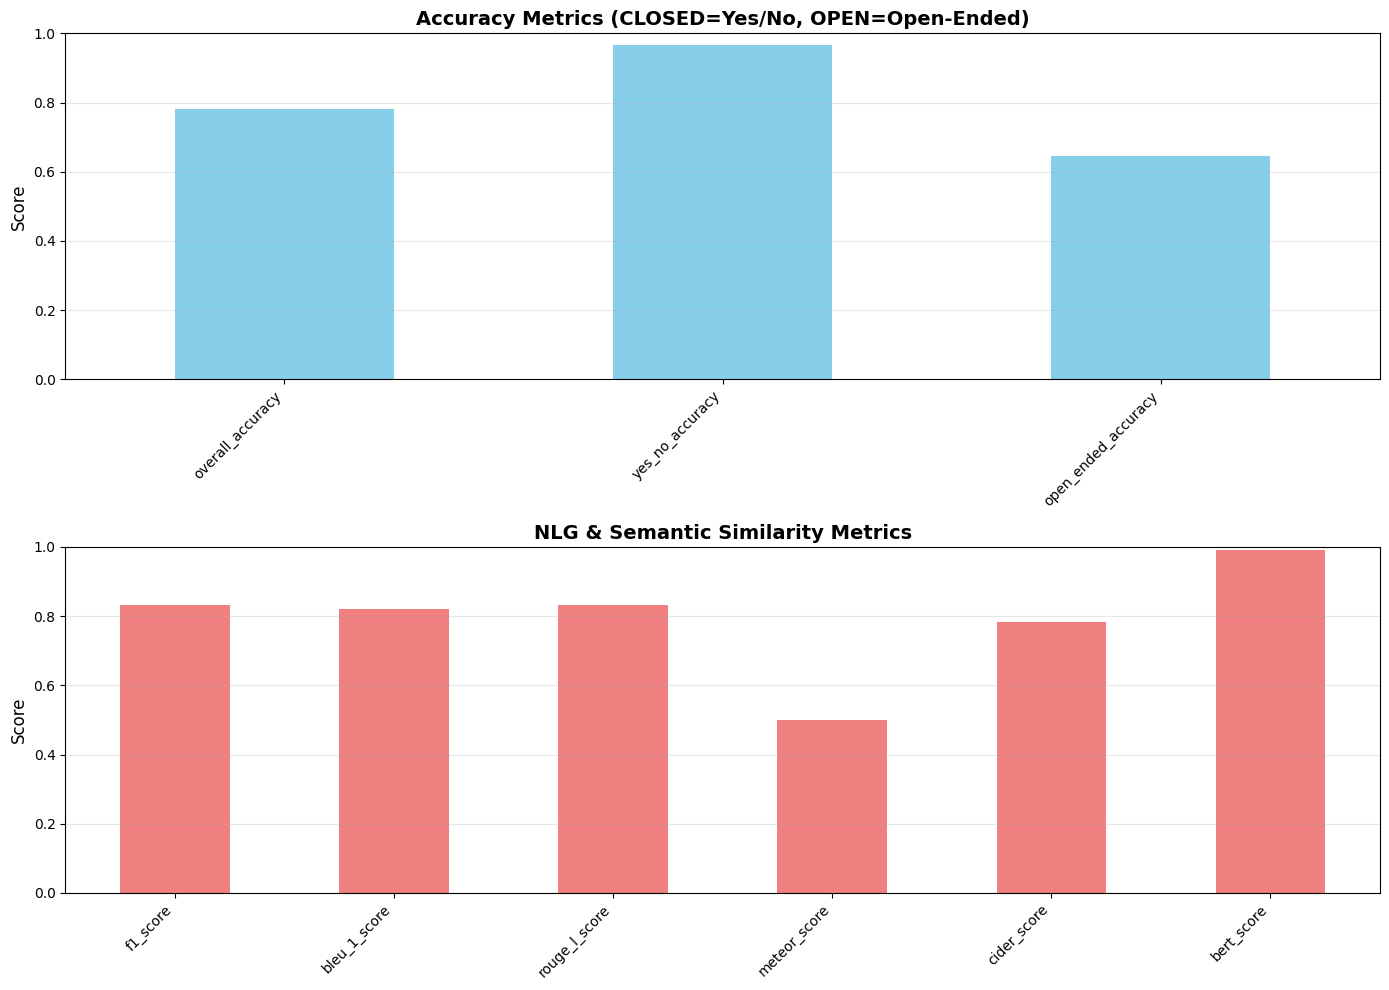

✅ Görselleştirme kaydedildi: ./reports/metrics_visualization.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sonuçları görselleştir
if 'results_df' in locals() and len(results_df) > 0:
    # Metrik sütunlarını seç
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Accuracy metrikleri (CLOSED ve OPEN)
    accuracy_cols = ['overall_accuracy', 'yes_no_accuracy', 'open_ended_accuracy']
    results_df[accuracy_cols].iloc[0].plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title('Accuracy Metrics (CLOSED=Yes/No, OPEN=Open-Ended)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Score', fontsize=12)
    axes[0].set_ylim([0, 1])
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

    # NLG ve Semantic metrikleri
    nlg_cols = ['f1_score', 'bleu_1_score', 'rouge_l_score', 'meteor_score', 'cider_score', 'bert_score']
    results_df[nlg_cols].iloc[0].plot(kind='bar', ax=axes[1], color='lightcoral')
    axes[1].set_title('NLG & Semantic Similarity Metrics', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_ylim([0, 1])
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig('./reports/metrics_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Görselleştirme kaydedildi: ./reports/metrics_visualization.png")
else:
    print("⚠️ Görselleştirme için sonuç bulunamadı.")
    print("💡 Lütfen önce değerlendirme hücresini (Cell 15) çalıştırın.")